In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("ecommerce.csv", low_memory=False)

print(df.head(5))

    Order ID Order Date Ship Date  Aging    Ship Mode    Product Category  \
0  AU-2015-1    11/9/15  11/17/15    8.0  First Class  Auto & Accessories   
1  AU-2015-2    6/30/15    7/2/15    2.0  First Class  Auto & Accessories   
2  AU-2015-3    12/5/15  12/13/15    8.0  First Class  Auto & Accessories   
3  AU-2015-4     5/9/15   5/16/15    7.0  First Class  Auto & Accessories   
4  AU-2015-5     7/9/15   7/18/15    9.0  First Class  Auto & Accessories   

             Product     Sales Quantity Discount  ... Shipping Cost  \
0  Car Media Players  $140.00         2     0.05  ...        $4.60    
1       Car Speakers  $211.00         3     0.03  ...       $11.20    
2    Car Body Covers  $117.00         5     0.01  ...        $3.10    
3    Car & Bike Care  $118.00         2     0.05  ...        $2.60    
4               Tyre  $250.00         1     0.04  ...       $16.00    

  Order Priority Customer ID    Customer Name      Segment        City  \
0         Medium      LS-001     Lan

In [4]:
print(df.dtypes)

Order ID                str
Order Date              str
Ship Date               str
Aging               float64
Ship Mode               str
Product Category        str
Product                 str
Sales                   str
Quantity                str
Discount                str
Profit                  str
Shipping Cost           str
Order Priority          str
Customer ID             str
Customer Name           str
Segment                 str
City                    str
State                   str
Country                 str
Region                  str
Months                  str
dtype: object


In [9]:
# 1. Convert Dates
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%y", errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%y",errors="coerce")

#2. Convert to Integer
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Cost"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("₹", "", regex=False)
    )

In [10]:
print(df["Order Date"].dtypes)
print(df["Order Date"].dtypes)


datetime64[us]
datetime64[us]


In [11]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")
df["Shipping Cost"] = pd.to_numeric(df["Shipping Cost"], errors="coerce")

In [12]:
#p1- Overall Sales Performance
print("Total Sales =", df["Sales"].sum())
print("Total Profit =", df["Profit"].sum())
print("Total Quantity =", df["Quantity"].sum())
print("Total Shipping Cost =", df["Shipping Cost"].sum())

Total Sales = 8023170.0
Total Profit = 3730073.3000000003
Total Quantity = 153729.0
Total Shipping Cost = 373021.4


Product
T - Shirts       692912.0
Titak watch      637260.0
Running Shoes    626080.0
Jeans            609092.0
Formal Shoes     595335.0
Shirts           547624.0
Fossil Watch     444564.0
Casula Shoes     340990.0
Suits            304655.0
Sports Wear      240295.0
Name: Sales, dtype: float64


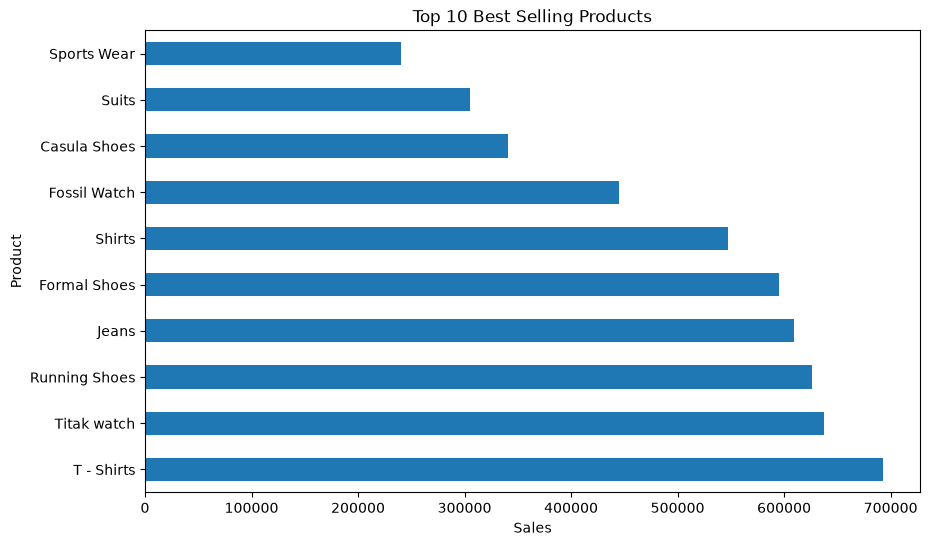

In [48]:
#2. Top 10 Best-Selling Products
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")
plt.title("Top 10 Best Selling Products")
plt.xlabel("Sales")
plt.show()

                        Sales     Profit  Quantity
Product Category                                  
Auto & Accessories  1096928.0   484313.2   22392.0
Electronic           394738.0   174190.6    8211.0
Fashion             5212097.0  2483955.2   92071.0
Home & Furniture    1319407.0   587614.3   31055.0


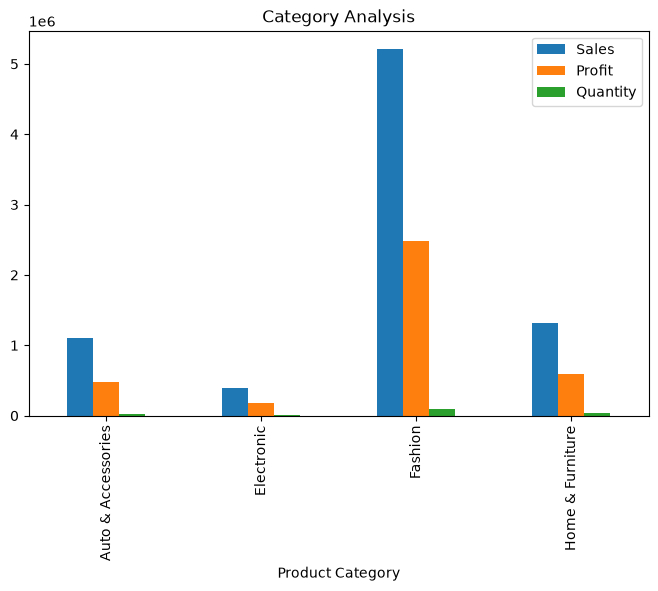

In [18]:
#3. Product Category Analysis
category = df.groupby("Product Category")[["Sales","Profit","Quantity"]].sum()

print(category)

category.plot(kind="bar", figsize=(8,5))
plt.title("Category Analysis")
plt.show()

Months
Apr    659404.0
Aug    670788.0
Dec    693073.0
Feb    610240.0
Jan    676313.0
Jul    685152.0
Jun    664560.0
Mar    686681.0
May    672547.0
Nov    656663.0
Oct    688905.0
Sep    658844.0
Name: Sales, dtype: float64


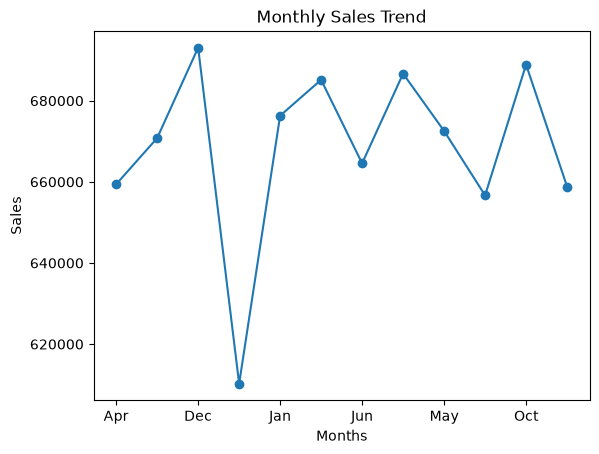

In [19]:
#4. Monthly Sales Trend
monthly_sales = df.groupby("Months")["Sales"].sum()

print(monthly_sales)

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

                    Sales    Profit
Region                             
4orth               117.0      33.5
Africa           713074.0  332220.0
Canada            60003.0   27783.1
Caribbean        260495.0  120608.1
Central         1735900.0  804210.0
Central Asia     321005.0  149529.7
EMEA             788072.0  368570.7
East             446468.0  206694.5
North            750365.0  349269.5
North Asia       369816.0  170918.3
Oceania          544827.0  253691.7
So3th               211.0      99.4
South           1034533.0  479016.5
Southeast Asia   500712.0  235598.1
West             497432.0  231775.8


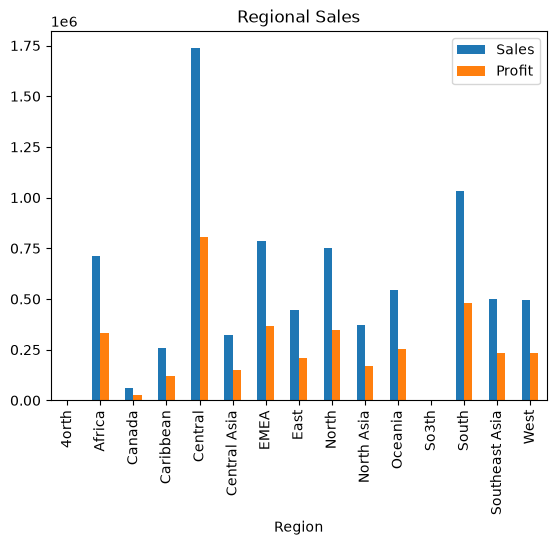

In [20]:
#5. Regional Sales Analysis
region = df.groupby("Region")[["Sales","Profit"]].sum()

print(region)

region.plot(kind="bar")
plt.title("Regional Sales")
plt.show()

Country
United States     1562170.0
Australia          442452.0
France             437441.0
Mexico             418795.0
Germany            323619.0
China              296640.0
United Kingdom     253975.0
Brazil             247794.0
India              244746.0
Indonesia          222379.0
Name: Sales, dtype: float64


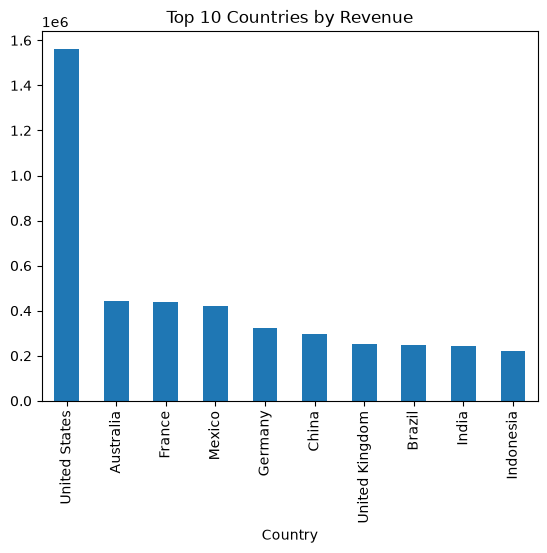

In [21]:
#6. Country-wise Revenue Analysis
country = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)
print(country)

country.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.show()

In [22]:
#7. State-wise Profit Analysis
profit = df.groupby("State")["Profit"].sum()

print("Top 15 States")
print(profit.sort_values(ascending=False).head(15))

print("Bottom 15 States")
print(profit.sort_values().head(15))

Top 15 States
State
California                142905.2
England                   109275.5
New York                   80855.4
Texas                      72492.1
Ile-de-France              70627.9
New South Wales            56253.6
Queensland                 52913.3
North Rhine-Westphalia     50167.2
San Salvador               45997.0
National Capital           43966.6
Pennsylvania               43675.1
Washington                 36666.3
Distrito Federal           34988.7
Illinois                   34632.3
Victoria                   34400.5
Name: Profit, dtype: float64
Bottom 15 States
State
Isparta               0.8
Kabarole              6.8
Inhambane             7.2
Caras-Severin        12.4
Savanes              15.6
Bitola               17.0
Guelmim-Es Semara    17.5
Ibb                  18.0
Shumen               19.5
Kara                 19.5
Okayama              20.3
South Chungcheong    20.3
Grand Gedeh          21.2
Novosibirsk          21.3
Mashonaland West     21.3
Name: Profit,

In [23]:
#8. Customer Segment Analysis
segment = df.groupby("Segment")[["Sales","Profit"]].sum()
segment["Average Order Value"] = df.groupby("Segment")["Sales"].mean()
print(segment)

                 Sales     Profit  Average Order Value
Segment                                               
Consumer     4135010.0  1915800.9           155.938077
Corporate    2421560.0  1128812.0           156.948603
Home Office  1466528.0   685446.0           156.982231


In [24]:
#9. Ship Mode Performance
ship = df.groupby("Ship Mode")[["Shipping Cost","Aging","Sales"]].mean()
print(ship)

                Shipping Cost     Aging       Sales
Ship Mode                                          
45788                0.600000  9.000000  114.000000
First Class          6.454165  5.541850  146.183393
Same Day             6.455313  1.000000  146.145131
Second Class         5.703114  5.454845  127.985935
Standard Class       8.070382  5.491503  169.361397


          Discount    Profit
Discount  1.000000 -0.119078
Profit   -0.119078  1.000000


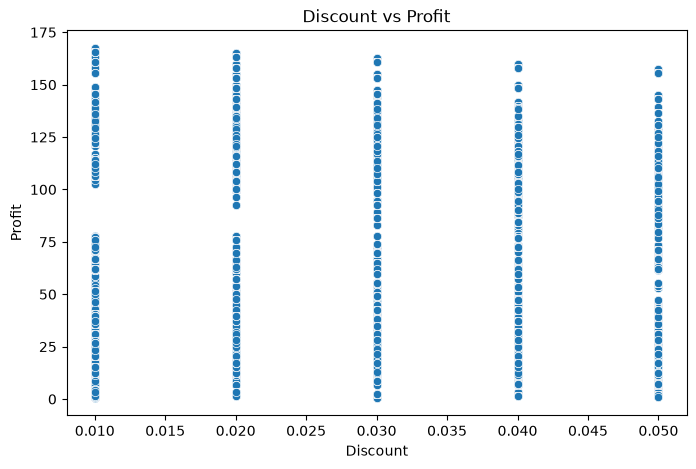

In [25]:
#10. Discount vs Profit Analysis
print(df[["Discount","Profit"]].corr())

plt.figure(figsize=(8,5))
sns.scatterplot(x="Discount", y="Profit", data=df)
plt.title("Discount vs Profit")
plt.show()

In [26]:
#11. Order Priority Analysis
priority = df.groupby("Order Priority")[["Sales","Profit"]].sum()
print(priority)

                    Sales     Profit
Order Priority                      
Critical         544404.0   239239.6
High            2348534.0  1081889.7
Low              411004.0   195904.5
Medium          4718747.0  2212750.8


In [27]:
#12. Top Customers Analysis
customer = df.groupby("Customer Name")[["Sales","Profit"]].sum()
print(customer.sort_values(by="Sales",ascending=False).head(20))

                     Sales  Profit
Customer Name                     
Mcclain O'Donnell  17015.0  7592.2
Weber Halladay     16632.0  7877.1
Leon Sissman       16321.0  7960.3
Booth Pistole      16291.0  7707.6
Ellis Carmichael   16174.0  7891.9
Bates Gockenbach   15968.0  7545.8
Bell Bickford      15932.0  7748.0
Spears Thornton    15922.0  7443.6
Graves Garza       15833.0  7830.7
Flores Brooks      15807.0  7250.5
Robertson Coakley  15635.0  7529.7
Kelly Braden       15593.0  7418.9
Skinner Nguyen     15332.0  7269.1
Ryan Dominguez     15160.0  7132.2
Mcdowell Roelle    15048.0  6838.7
Preston Savely     15010.0  7165.0
Barnett Garverick  14946.0  7321.4
Wiley Pölking      14883.0  7234.3
Oneill Williams    14719.0  6853.8
Meyers Pelletier   14637.0  6772.8


In [34]:
#13. Loss-Making Orders
loss = df[df["Profit"] < 0]
if loss.empty:
    print("No loss-making orders found in the dataset.")
else:
    print(loss[["Order ID","Product","Discount","Profit","Shipping Cost","Product Category"]])

No loss-making orders found in the dataset.


Ship Mode
45788             9.000000
First Class       5.541850
Same Day          1.000000
Second Class      5.454845
Standard Class    5.491503
Name: Aging, dtype: float64


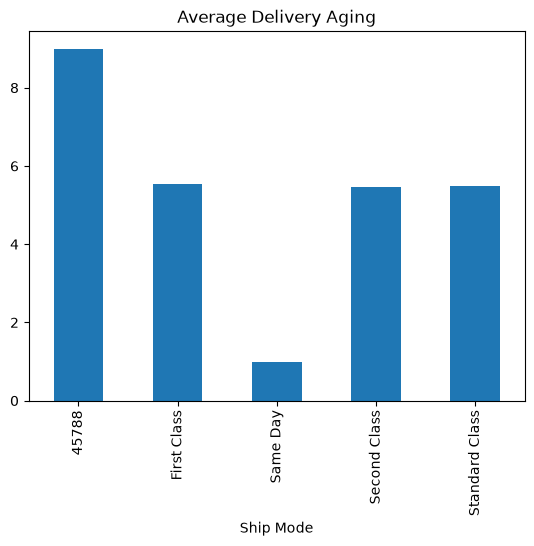

In [35]:
#14. Aging Analysis
aging = df.groupby("Ship Mode")["Aging"].mean()

print(aging)

aging.plot(kind="bar")
plt.title("Average Delivery Aging")
plt.show()

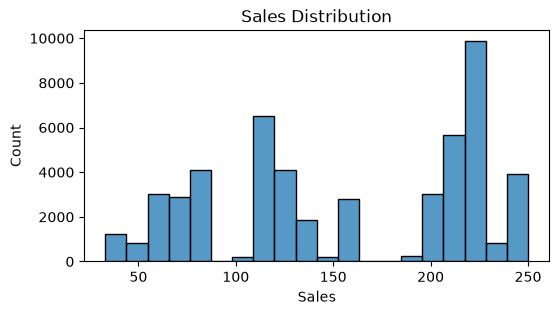

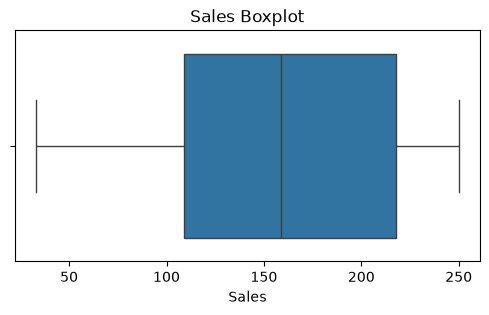

In [40]:
#15. Sales Distribution
plt.figure(figsize=(6,3))
sns.histplot(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df["Sales"])
plt.title("Sales Boxplot")
plt.show()

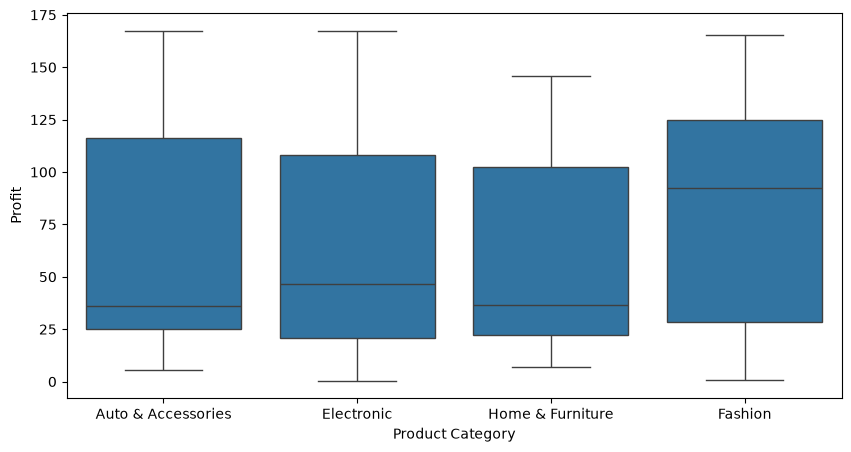

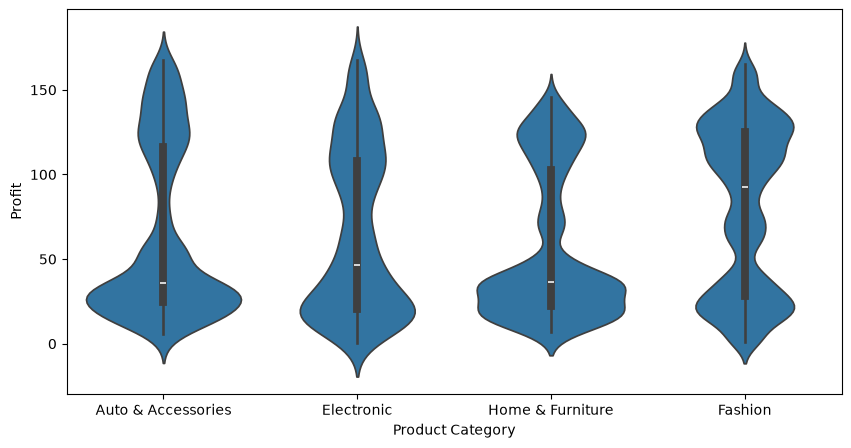

In [41]:
#16. Profit Distribution by Category
plt.figure(figsize=(10,5))
sns.boxplot(x="Product Category", y="Profit", data=df)
plt.show()

plt.figure(figsize=(10,5))
sns.violinplot(x="Product Category", y="Profit", data=df)
plt.show()

                  Sales  Quantity  Discount    Profit  Shipping Cost     Aging
Sales          1.000000 -0.000573 -0.007228  0.921516       0.921262  0.014835
Quantity      -0.000573  1.000000  0.007131 -0.176278      -0.176640 -0.002449
Discount      -0.007228  0.007131  1.000000 -0.119078      -0.119391  0.000132
Profit         0.921516 -0.176278 -0.119078  1.000000       0.999982  0.015231
Shipping Cost  0.921262 -0.176640 -0.119391  0.999982       1.000000  0.015170
Aging          0.014835 -0.002449  0.000132  0.015231       0.015170  1.000000


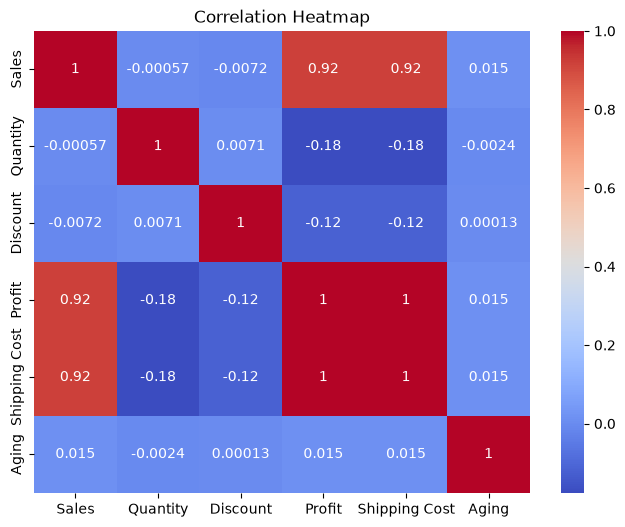

In [42]:
#17. Correlation Analysis
corr = df[["Sales","Quantity","Discount","Profit","Shipping Cost","Aging"]].corr()

print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [44]:
#18. High-Value Orders
avg_sales = df["Sales"].mean()
high = df[df["Sales"]>avg_sales]
print(high)

            Order ID Order Date  Ship Date  Aging       Ship Mode  \
1          AU-2015-2 2015-06-30 2015-07-02    2.0     First Class   
4          AU-2015-5 2015-07-09 2015-07-18    9.0     First Class   
8          AU-2015-9 2015-02-09 2015-02-16    7.0     First Class   
10        AU-2015-11 2015-11-16 2015-11-26   10.0     First Class   
13        AU-2015-14 2015-07-22 2015-07-27    5.0     First Class   
...              ...        ...        ...    ...             ...   
51249  FA-2015-30735 2015-06-03 2015-06-10    7.0  Standard Class   
51253  FA-2015-30739 2015-03-25 2015-04-01    7.0  Standard Class   
51254  FA-2015-30740 2015-09-16 2015-09-18    2.0  Standard Class   
51256  FA-2015-30742 2015-02-21 2015-02-28    7.0  Standard Class   
51257  FA-2015-30743 2015-02-24 2015-03-03    7.0  Standard Class   

         Product Category                 Product  Sales  Quantity  Discount  \
1      Auto & Accessories            Car Speakers  211.0       3.0      0.03   
4      Auto

In [45]:
#19. Customer Purchase Frequency
orders = df.groupby("Customer Name")["Order ID"].count()

print("Highest Orders")
print(orders.sort_values(ascending=False).head(20))

print("Average Order Value")
print(df.groupby("Customer Name")["Sales"].mean())

print("Repeat Customers")
print(orders[orders>1])

Highest Orders
Customer Name
Mcclain O'Donnell    108
Spears Thornton      106
Bates Gockenbach     102
Flores Brooks        102
Booth Pistole        102
Weber Halladay       101
May Französisch      100
Bell Bickford         98
Ellis Carmichael      97
Robertson Coakley     96
Kelly Braden          96
Maldonado Jenkins     95
Bond Overcash         95
Skinner Nguyen        94
Graves Garza          94
Ryan Dominguez        94
Dotson Weiss          93
Saunders Kotsonis     93
Meyers Pelletier      92
Wiley Pölking         92
Name: Order ID, dtype: int64
Average Order Value
Customer Name
Abbott Mackendrick        160.412698
Acosta Morse              166.935484
Adams Barchas             135.485714
Adkins Jones              151.654321
Aguilar Hopkins           145.906667
                             ...    
Wyatt Pak                 153.048387
Yates Johnson             156.289157
York Redmond              152.101449
Young Avila               153.180328
Zimmerman Lichtenstein    166.410714
N